# Syn Bank Share of Wallet Intelligence Engine

Ingestion + profiling only (PLAN.md Section 5, steps 1-3). No modeling logic yet.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

DATA_DIR = Path.cwd()

print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"Data directory: {DATA_DIR.resolve()}")

pandas 3.0.0 | numpy 2.2.1
Data directory: C:\Users\ADMIN\Downloads\Hackathon


## 2. Ingestion

Loads the 3 Syn Bank internal datasets. `transactional_banking.csv` is ~2.8M rows / ~390MB, so this cell may take a minute.

In [2]:
df_txn = pd.read_csv(DATA_DIR / "transactional_banking.csv", parse_dates=["date"])
df_xborder = pd.read_csv(DATA_DIR / "cross_border_payments.csv", parse_dates=["date"])
df_trade = pd.read_csv(DATA_DIR / "trade_finance.csv", parse_dates=["date"])

datasets = {
    "transactional_banking": df_txn,
    "cross_border_payments": df_xborder,
    "trade_finance": df_trade,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} cols")

transactional_banking: 2,802,875 rows x 13 cols
cross_border_payments: 241,117 rows x 13 cols
trade_finance: 20,303 rows x 15 cols


## 3. Profiling

For each dataset: row count, date range, unique entity counts, and null counts per column.

In [3]:
def profile(df: pd.DataFrame, name: str) -> None:
    print("=" * 80)
    print(name)
    print("=" * 80)
    print(f"Rows: {len(df):,}")
    print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
    print(f"Unique entity_id: {df['entity_id'].nunique()}")
    print(f"Unique entity_name: {df['entity_name'].nunique()}")

    null_summary = pd.DataFrame({
        "null_count": df.isnull().sum(),
        "null_pct": (100 * df.isnull().mean()).round(2),
    })
    print("\nNull counts per column:")
    print(null_summary)
    print()


for name, df in datasets.items():
    profile(df, name)

transactional_banking
Rows: 2,802,875
Date range: 2023-07-01 -> 2026-06-30


Unique entity_id: 20
Unique entity_name: 20



Null counts per column:
                  null_count  null_pct
transaction_id             0      0.00
entity_id                  0      0.00
entity_name                0      0.00
sector                     0      0.00
date                       0      0.00
leg_type                   0      0.00
direction                  0      0.00
amount_zar                 0      0.00
currency                   0      0.00
channel                    0      0.00
beneficiary_name           0      0.00
reference                  0      0.00
memo                 2799218     99.87

cross_border_payments
Rows: 241,117
Date range: 2023-07-01 -> 2026-06-30
Unique entity_id: 20
Unique entity_name: 20

Null counts per column:
                      null_count  null_pct
transaction_id                 0      0.00
entity_id                      0      0.00
entity_name                    0      0.00
sector                         0      0.00
date                           0      0.00
direction                   

## 4. Entity list sanity check

Confirms the entities present in the data match the 20 names confirmed in PLAN.md Section 3.

In [4]:
PLAN_ENTITIES = {
    "Anglo American", "AngloGold Ashanti", "Aspen Pharmacare", "BHP Group",
    "Bid Corporation", "Clicks Group", "Glencore", "Gold Fields", "MTN Group",
    "NEPI Rockcastle", "Naspers", "OUTsurance Group", "Pepkor Holdings",
    "Prosus", "Sanlam", "Shaftesbury Capital plc", "Shoprite Holdings",
    "The Bidvest Group", "Valterra Platinum", "Vodacom Group",
}

data_entities = set()
for name, df in datasets.items():
    data_entities |= set(df["entity_name"].unique())

print(f"Entities found across all 3 datasets: {len(data_entities)}")
print(f"Entities listed in PLAN.md Section 3: {len(PLAN_ENTITIES)}")

missing_from_data = PLAN_ENTITIES - data_entities
extra_in_data = data_entities - PLAN_ENTITIES

if not missing_from_data and not extra_in_data:
    print("\nMATCH -- data entity list is identical to PLAN.md Section 3.")
else:
    print("\nMISMATCH")
    if missing_from_data:
        print(f"  In PLAN.md but not in data: {sorted(missing_from_data)}")
    if extra_in_data:
        print(f"  In data but not in PLAN.md: {sorted(extra_in_data)}")

for name, df in datasets.items():
    entities_here = set(df["entity_name"].unique())
    if entities_here != data_entities:
        print(f"NOTE: {name} does not cover all entities -- missing {data_entities - entities_here}")

Entities found across all 3 datasets: 20
Entities listed in PLAN.md Section 3: 20

MATCH -- data entity list is identical to PLAN.md Section 3.


## 5. Internal wallet share by product pillar

Per `docs/superpowers/specs/2026-08-08-pillar-spend-split-design.md` (approved): split each client's captured Syn Bank activity into the 3 product pillars — Transactional Banking, Trade & Working Capital, Foreign/Cross-Border — using the **trailing 12 months** (2025-07-01 → 2026-06-30) and **gross flow** (both directions summed).

Heavy lifting (loading the 2.8M-row `transactional_banking.csv`) lives in `scripts/build_pillar_spend.py` for speed/reproducibility — this notebook loads its output.

In [5]:
EXTRACTED_DIR = DATA_DIR / "hackathon-finreports" / "_extracted"

pillar_wide = pd.read_csv(EXTRACTED_DIR / "pillar_spend_wide.csv")
pillar_cols = ["Transactional Banking", "Trade & Working Capital", "Foreign / Cross-Border"]

print(f"{len(pillar_wide)} clients x 3 pillars, trailing 12mo gross flow (ZAR)")
pillar_wide[["entity_name", "sector"] + pillar_cols + ["total_internal_spend_zar"]].sort_values(
    "total_internal_spend_zar", ascending=False
)

20 clients x 3 pillars, trailing 12mo gross flow (ZAR)


,entity_name,sector,Transactional Banking,Trade & Working Capital,Foreign / Cross-Border,total_internal_spend_zar
10,Pepkor Holdings,consumer,3.419505e+10,1.533077e+09,6.655520e+09,4.238365e+10
7,Sanlam,insurance,1.924748e+10,1.523362e+08,2.664890e+09,2.206471e+10
9,Bid Corporation,consumer,1.292806e+10,1.878699e+09,6.165601e+09,2.097236e+10
0,BHP Group,mining,1.678772e+10,1.444550e+09,2.082856e+09,2.031512e+10
15,MTN Group,telecoms,1.043628e+10,1.443169e+09,6.209646e+09,1.808910e+10
8,Shoprite Holdings,consumer,1.059335e+10,1.539091e+09,3.356218e+09,1.548866e+10
2,Anglo American,mining,7.557961e+09,6.320166e+08,9.963789e+08,9.186357e+09
1,Glencore,mining,4.440268e+09,1.085074e+09,2.323926e+09,7.849268e+09
17,The Bidvest Group,industrials_pharma,4.730574e+09,1.464031e+09,1.614258e+09,7.808863e+09
18,Aspen Pharmacare,industrials_pharma,3.552116e+09,5.324227e+08,1.412987e+09,5.497526e+09


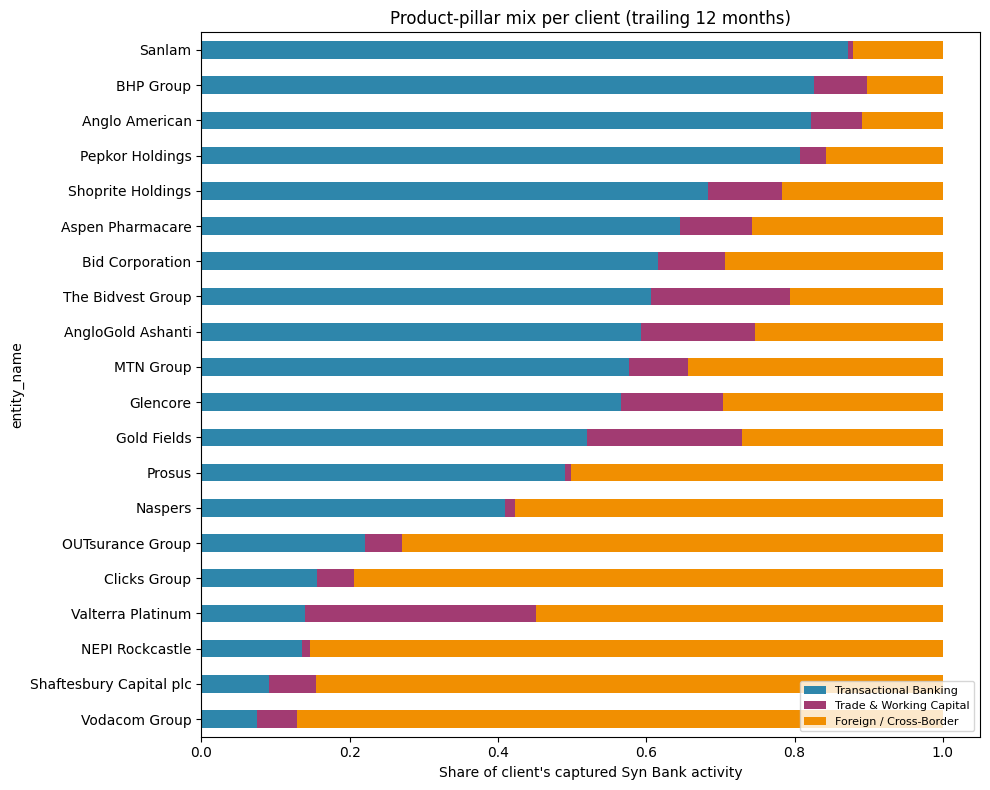

In [6]:
pct_cols = [f"{c} % of total" for c in pillar_cols]
plot_df = pillar_wide.set_index("entity_name")[pct_cols].sort_values(pct_cols[0])

fig, ax = plt.subplots(figsize=(10, 8))
plot_df.plot(kind="barh", stacked=True, ax=ax, color=["#2E86AB", "#A23B72", "#F18F01"])
ax.set_xlabel("Share of client's captured Syn Bank activity")
ax.set_title("Product-pillar mix per client (trailing 12 months)")
ax.legend(pillar_cols, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 6-7. External wallet estimation (top-down) + Wallet model

**Scope decision (solo build, time-constrained):** top-down financials-based Total Wallet proxy only — bottom-up competitor evidence (SARB BA900, JSE SENS) was cut from this pass, see `DATA_SOURCES.md`. Full methodology and the reliability-tiering fix (see below) are documented in `docs/reports/2026-08-13-wallet-model-summary.md`.

**Important caveat surfaced by this model, not hidden:** a naive proxy (= consolidated group revenue) produces a nonsensical multi-trillion-Rand "gap" for globally-diversified multinationals (Glencore, BHP, Anglo American, etc.) because their group revenue reflects *worldwide* operations, not the SA-specific slice Syn Bank could plausibly capture. Every row below is tagged with `top_down_reliability`:
- `moderate` — ZAR reporter, figures are for the SA-listed entity itself, Rand gap is reasonably literal.
- `low` — foreign-currency (USD/EUR/GBP) reporter, Rand gap is directional only, don't sum into a portfolio total.
- `insufficient` — Bidvest: only company-level (not Group) AFS was ever found, Pillar 1 wallet unknown, blended total correctly left blank.

In [7]:
wallet_model = pd.read_csv(EXTRACTED_DIR / "wallet_model.csv")

display_cols = [
    "entity_name", "sector", "top_down_reliability",
    "share_pct_pillar1", "share_pct_pillar2", "share_pct_pillar3",
    "total_internal_zar_m", "total_wallet_zar_m", "blended_share_pct", "total_gap_zar_m",
]
wallet_model[display_cols].sort_values("total_gap_zar_m", ascending=False, na_position="last")

,entity_name,sector,top_down_reliability,share_pct_pillar1,share_pct_pillar2,share_pct_pillar3,total_internal_zar_m,total_wallet_zar_m,blended_share_pct,total_gap_zar_m
0,Glencore,mining,low - foreign reporting currency; consolidated...,0.1,0.1,NaN,7849.267800,9.508822e+06,0.1,9500972.7
1,BHP Group,mining,low - foreign reporting currency; consolidated...,2.0,0.5,NaN,20315.123914,1.128830e+06,1.8,1108515.0
2,Anglo American,mining,low - foreign reporting currency; consolidated...,2.5,0.3,NaN,9186.356661,5.119176e+05,1.8,502731.2
3,Shoprite Holdings,consumer,"moderate - ZAR reporter, financials are for th...",2.4,2.7,NaN,15488.659043,5.056690e+05,3.1,490180.3
4,Bid Corporation,consumer,"moderate - ZAR reporter, financials are for th...",3.1,2.3,NaN,20972.361438,4.944375e+05,4.2,473465.1
5,MTN Group,telecoms,"moderate - ZAR reporter, financials are for th...",4.6,NaN,3.5,18089.100089,4.062589e+05,4.5,388169.8
6,Naspers,tech,low - foreign reporting currency; consolidated...,0.8,0.3,2.1,3557.985676,3.020283e+05,1.2,298470.3
7,AngloGold Ashanti,mining,low - foreign reporting currency; consolidated...,0.8,1.1,NaN,3346.136740,2.913841e+05,1.1,288038.0
8,Vodacom Group,telecoms,"moderate - ZAR reporter, financials are for th...",0.2,0.2,4.7,3341.054273,2.889873e+05,1.2,285646.2
9,Valterra Platinum,mining,"moderate - ZAR reporter, financials are for th...",0.0,0.2,NaN,369.484073,2.630510e+05,0.1,262681.5


## 8. Opportunity ranking

Ranked by total Rand gap. Split into the **actionable tier** (ZAR reporters — read the Rand figure literally) vs. the full list (includes low-reliability multinational rows, where only the % share is trustworthy).

=== Actionable tier - top opportunities by Rand gap (ZAR reporters only) ===
      entity_name             sector data_vintage_flag  total_internal_zar_m  total_wallet_zar_m  blended_share_pct  total_gap_zar_m
Shoprite Holdings           consumer           current          15488.659043         505669.0000                3.1         490180.3
  Bid Corporation           consumer           current          20972.361438         494437.5000                4.2         473465.1
        MTN Group           telecoms           current          18089.100089         406258.9440                4.5         388169.8
    Vodacom Group           telecoms           current           3341.054273         288987.2755                1.2         285646.2
Valterra Platinum             mining           current            369.484073         263051.0000                0.1         262681.5
  Pepkor Holdings           consumer           current          42383.649761         202842.0000               20.9         1

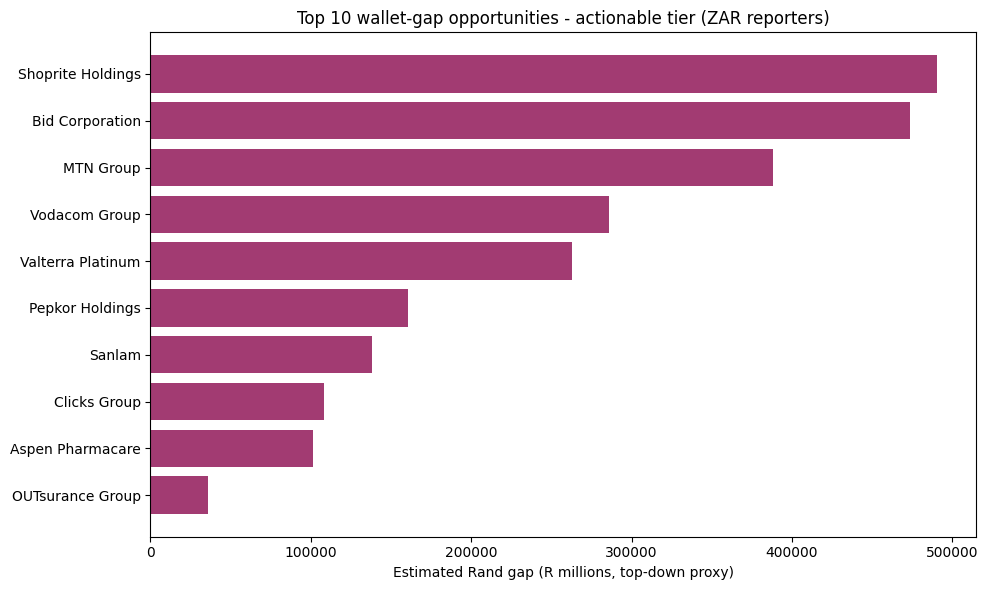

In [8]:
ranking = pd.read_csv(EXTRACTED_DIR / "opportunity_ranking.csv")
actionable = ranking[ranking["top_down_reliability"].str.startswith("moderate")].copy()

print("=== Actionable tier - top opportunities by Rand gap (ZAR reporters only) ===")
display_ranking_cols = ["entity_name", "sector", "data_vintage_flag", "total_internal_zar_m", "total_wallet_zar_m", "blended_share_pct", "total_gap_zar_m"]
print(actionable[display_ranking_cols].head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top10 = actionable.head(10).sort_values("total_gap_zar_m")
ax.barh(top10["entity_name"], top10["total_gap_zar_m"], color="#A23B72")
ax.set_xlabel("Estimated Rand gap (R millions, top-down proxy)")
ax.set_title("Top 10 wallet-gap opportunities - actionable tier (ZAR reporters)")
plt.tight_layout()
plt.show()